[Project Stone]
- 돌 분류 프로젝트

In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
numlist = os.listdir('./_data/open/train')
trainDIR = './_data/open/train'
sum = 0

for i in numlist:
    a = (len(os.listdir('./_data/open/train/'+i)))
    print(i, a)
    sum += a
print(sum)

Andesite 43802
Basalt 26810
Etc 15935
Gneiss 73914
Granite 92923
Mud_Sandstone 89467
Weathered_Rock 37169
380020


In [3]:
numlist = os.listdir('./_data/open/test')
testDIR = './_data/open/test'
len(numlist)

95006

In [4]:
## 작업순서
## 데이테 셋 만들기 
## 데이터 로더 만들기
## 폴더별로 되있으니까 imgeafolder사용하면 될듯?


In [5]:
import torch
import torch.nn as nn
from torch.nn import functional as F

from torch.utils.data import Dataset, DataLoader  # Pytorch의 데이터셋 관련
from torchvision import transforms  # 전처리모듈
from torchvision.datasets import ImageFolder

from PIL import Image


In [6]:
TRANSFORM = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
])



In [7]:
classes = ['Andesite', 'Basalt', 'Gneiss', 'Granite', 'Mud_Sandstone', 'Weathered_Rock']
classes2idx = {x:idx+1 for idx,x in enumerate(classes)}
classes2idx['Etc']= 0
classes2idx

{'Andesite': 1,
 'Basalt': 2,
 'Gneiss': 3,
 'Granite': 4,
 'Mud_Sandstone': 5,
 'Weathered_Rock': 6,
 'Etc': 0}

In [8]:

class CustomImageFolder(ImageFolder):
    def __init__(self, root, transform=None, classes2idx=classes2idx):
        self.classes2idx = classes2idx
        self.class_to_idx = self.classes2idx
        self.classes = list(classes2idx.keys())
        super().__init__(root, transform)

    def find_classes(self, directory):
        # 이 함수가 자동 클래스 탐색을 담당하는데, 우리가 원하는 대로 덮어씀
        return self.classes, self.classes2idx

In [9]:
trainDS = CustomImageFolder(trainDIR, transform=TRANSFORM, classes2idx=classes2idx)

In [10]:
print('train', len(trainDS))
print(trainDS.classes)
trainDS.class_to_idx
idx2class = {values:key for key, values in classes2idx.items()}
idx2class

train 380020
['Andesite', 'Basalt', 'Gneiss', 'Granite', 'Mud_Sandstone', 'Weathered_Rock', 'Etc']


{1: 'Andesite',
 2: 'Basalt',
 3: 'Gneiss',
 4: 'Granite',
 5: 'Mud_Sandstone',
 6: 'Weathered_Rock',
 0: 'Etc'}

In [11]:
trainDS[111100][0].shape

torch.Size([3, 224, 224])

In [12]:
cnum = 0
for (a, b) in trainDS:
    cnum += 1
    print(a[0].shape, idx2class[b])
    if cnum == 10: break
    

torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite
torch.Size([224, 224]) Andesite


In [13]:
from torch.utils.data import random_split

# 전체 데이터 수
total_size = len(trainDS)
train_size = int(0.8 * total_size)
valid_size = total_size - train_size

# 무작위로 train/valid 분리
trainDS, validDS = random_split(trainDS, [train_size, valid_size])

In [14]:
print(len(trainDS))
print(len(validDS))

304016
76004


In [15]:

imgTS, label = trainDS[0]   ## __getitem__(index)
print(imgTS.shape, label)


torch.Size([3, 224, 224]) 4


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1134453].


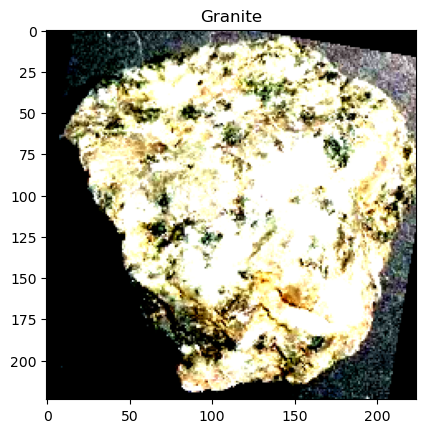

In [17]:
plt.imshow(imgTS.permute(1,2,0))
plt.title(idx2class[label])
plt.show()

In [18]:
def collator(batch):
    images, labels = zip(*batch)  # 튜플 of Tensors
    images = torch.stack(images)  # → Tensor of shape [B, C, H, W]
    labels = torch.tensor(labels) # → Tensor of shape [B]
    return images, labels

BATCH_SIZE = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 0.0001

In [19]:
trainDL = DataLoader(
    trainDS, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator
)
validDL = DataLoader(
    validDS, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collator
)

In [20]:
for a, b in trainDL:
    print((type(a)),(type(b)))
    break

<class 'torch.Tensor'> <class 'torch.Tensor'>


In [21]:
from torchvision import models
from torchvision import ops
from torchvision.models.detection import rpn

num_classes = len(classes2idx)
num_classes

7

In [22]:
# ✅ 모델: ResNet101 + 마지막 fc 교체
model = models.resnet101(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)


c:\Users\kdt\anaconda3\envs\DL_TORCH\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kdt\anaconda3\envs\DL_TORCH\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
from torch import optim
from tqdm import tqdm
# ✅ 손실함수, 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [24]:
EPOCH = 1
best_val_loss = 10.0
patience = 3  # 몇 번 연속 향상 없을 때 중단할지
patience_counter = 0

for epoch in range(EPOCH):
    # ----------- Training -----------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_loop = tqdm(trainDL, desc=f"[Epoch {epoch+1}] Training")
    for images, labels in train_loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        train_loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    train_acc = 100. * correct / total
    train_loss = running_loss / len(trainDL)

    # ----------- Validation -----------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in validDL:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    if val_loss >= best_val_loss and val_loss < 2:
        model._save_to_state_dict(torch.load(f"./_model/{epoch}_vl{val_loss:.2f}.pth"))
    
    val_acc = 100. * val_correct / val_total
    val_loss_avg = val_loss / len(validDL)

    print(f"\n[Epoch {epoch+1}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"                    Valid Loss: {val_loss_avg:.4f}, Valid Acc: {val_acc:.2f}%")

    


[Epoch 1] Training:   0%|          | 12/3040 [14:55<62:45:27, 74.61s/it, acc=52.2, loss=0.939]


KeyboardInterrupt: 

In [ ]:
sampleDF = pd.DataFrame(pd.read_csv('./_data/open/sample_submission.csv'))
print(sampleDF.head())
testDF = pd.DataFrame(pd.read_csv('./_data/open/test.csv'))
print(testDF.head())

In [ ]:
class TestImageDataset(Dataset):
    def __init__(self, csv_df, image_root, transform=None):
        self.df = csv_df
        self.image_root = image_root  # 예: './_data/open/test/'
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx): 
        img_name = self.df.iloc[idx, 0]
        img_path = self.df.iloc[idx, 1]
        img_path = os.path.join(self.image_root, img_path)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_name


In [ ]:
TRANSFORM_T = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
])



In [ ]:
testDS = TestImageDataset(testDF, image_root="./_data/open/", transform=TRANSFORM_T)
testDL = DataLoader(testDS, batch_size=32, shuffle=False)

In [ ]:
for a, b in testDS:
    print(a,b)
    break

In [ ]:
model.eval()
predictions = []

with torch.no_grad():
    count = 0
    for images, filenames in testDL:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        for fname, pred in zip(filenames, preds):
            predictions.append((fname, idx2class[pred.item()]))
        count += 1
        if count ==3: break

In [ ]:
sampleDF.head()

In [ ]:
predictions

In [ ]:
sampleDF.shape[0]

In [ ]:
# for i in range(sampleDF.shape[0]):
for i in range(20):
    if sampleDF.loc[i,'ID'] == predictions[i][0]:
        sampleDF.loc[i,'rock_type'] = predictions[i][1]
    else:
        continue
sampleDF.head(20)

In [ ]:
sampleDF.to_csv('./_data/open/sample_submission_answer.csv')